
# Solution Key to Assignment on Support Vector Machines


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

np.random.seed(7)

## Question 1 — Hyperplane and margin

A linear SVM decision boundary is:

$$
w^T x + b = 0
$$

### 1. What is a hyperplane in high-dimensional gene expression space?
A hyperplane is a flat decision boundary in feature space. If there are \(p\) genes, each sample is a point in \(p\)-dimensional space, and the hyperplane has dimension \(p-1\).

### 2. What is the margin?
The margin is the perpendicular distance between the decision boundary and the closest training points from either class. SVM chooses the boundary with the largest possible margin.

### 3. Why is the distance to $w^T x + b = 1$ equal to $1/\|w\|$?
The distance from a point $x$ to the hyperplane $(w^T x + b = 0)$ is:

$$
\frac{|w^T x + b|}{\|w\|}
$$

For a point on the upper margin boundary, $w^T x + b = 1$, so the distance is:

$$
\frac{|1|}{\|w\|} = \frac{1}{\|w\|}
$$

Maximizing this distance improves generalization because it makes the classifier more robust to small perturbations and noise.


## Question 2 — Hinge loss and slack variables

Hinge loss is:

$$
L(y_i, z_i) = \max(0, 1 - y_i z_i)
$$

We compute the four losses below.

In [2]:
examples = pd.DataFrame({
    "Sample": [1, 2, 3, 4],
    "y": [1, 1, -1, -1],
    "z": [2.5, 0.7, -0.2, 1.0]
})

examples["y*z"] = examples["y"] * examples["z"]
examples["hinge_loss"] = np.maximum(0, 1 - examples["y*z"])

def classify_case(z):
    if z >= 1:
        return "correctly classified outside margin"
    elif z > 0:
        return "correctly classified inside margin"
    else:
        return "misclassified"

examples["interpretation"] = examples["y*z"].apply(classify_case)
examples


,Sample,y,z,y*z,hinge_loss,interpretation
0,1,1,2.5,2.5,0.0,correctly classified outside margin
1,2,1,0.7,0.7,0.3,correctly classified inside margin
2,3,-1,-0.2,0.2,0.8,correctly classified inside margin
3,4,-1,1.0,-1.0,2.0,misclassified


Slack variables are equivalent to hinge losses for soft-margin SVM:
$$
\xi_i = \max(0, 1 - y_i z_i)
$$


## Question 3: Linear SVM on a Gene Expression Dataset


In [3]:
in_file_name = "gene_expression_binary.csv"
df = pd.read_csv(in_file_name)

print(df.head())

     Gene_1    Gene_2    Gene_3    Gene_4    Gene_5    Gene_6    Gene_7  \
0  0.165362  1.052481  0.250059  0.647174  0.999504  7.399953 -0.139929   
1 -0.780324 -0.108025  0.716442  0.435419 -0.609848 -0.242195 -0.439404   
2  0.231719 -1.680229 -0.565501 -0.042879 -0.494839  4.032141  0.764033   
3  0.491246  0.388259 -1.901445  1.927810  0.204609  4.682180  0.168620   
4 -2.448968  2.164372 -0.509130 -0.013008  1.309486 -2.768720 -0.479120   

     Gene_8    Gene_9   Gene_10  ...  Gene_292  Gene_293   Gene_294  Gene_295  \
0 -0.825100 -1.731810  0.490245  ...  1.835600  1.515755  -0.091484 -0.932527   
1  0.193077  2.019842  1.014541  ...  1.146299  0.978062 -12.977023 -0.012661   
2 -1.069174  0.868155  1.517235  ...  0.307717 -1.219386  17.469884 -1.112189   
3 -0.259217 -0.272536 -0.005169  ...  0.628027  0.454545  -6.172395 -1.510199   
4  0.468360 -1.277465 -0.972258  ...  1.002873 -0.736546  -0.641376  0.128546   

   Gene_296  Gene_297  Gene_298  Gene_299  Gene_300  disease_l

## (A) Split data into training/test

We split the data into training and test sets, then standardize the features.


In [4]:
X = df.drop(columns=["disease_label"]).values
feature_names = df.drop(columns=["disease_label"]).columns.tolist()

y = df["disease_label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=7
)

print("Training shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Training class counts:", np.bincount(y_train))
print("Test class counts:", np.bincount(y_test))


Training shape: (126, 300)
Test shape: (54, 300)
Training class counts: [63 63]
Test class counts: [27 27]


## (B) Standardize variables

In [5]:
linear_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(kernel="linear", C=1.0))
])

## (C) Why scaling is necessary for SVM
SVM relies on distances and dot products. If one gene has a much larger numeric scale than another, it can dominate the optimization. Standardization makes each feature comparable by putting them on a similar scale.

## (D) Train a SVM model

In [6]:
linear_pipeline.fit(X_train, y_train)

y_train_pred = linear_pipeline.predict(X_train)
y_test_pred = linear_pipeline.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

svm_linear = linear_pipeline.named_steps["svm"]

## (E) Report

In [7]:
print("Training accuracy:", round(train_acc, 4))
print("Test accuracy:", round(test_acc, 4))
print("Number of support vectors:", len(svm_linear.support_))
print("Support vectors per class:", svm_linear.n_support_)

Training accuracy: 1.0
Test accuracy: 0.8148
Number of support vectors: 107
Support vectors per class: [54 53]


## (F) What the number of support vectors indicates

- A **large fraction of support vectors** suggests the classes are overlapping, noisy, or difficult to separate.
- A **small fraction of support vectors** suggests a cleaner separation.



## Bonus understanding — Feature importance interpretation

For a **linear** SVM, the coefficients define the separating hyperplane. Features with large absolute coefficients contribute more strongly to the decision function.

Because we standardized the features, the coefficients are comparable across genes.


In [ ]:
coef = svm_linear.coef_[0]
coef_series = pd.Series(coef, index=feature_names)

top15 = coef_series.reindex(coef_series.abs().sort_values(ascending=False).index).head(15)
top15_df = pd.DataFrame({
    "gene": top15.index,
    "coefficient": top15.values,
    "abs_coefficient": np.abs(top15.values)
})
top15_df


In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(top15_df["gene"], top15_df["abs_coefficient"])
plt.xticks(rotation=75)
plt.ylabel("Absolute coefficient")
plt.title("Top 15 genes by |linear SVM coefficient|")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(coef, bins=40)
plt.xlabel("Coefficient value")
plt.ylabel("Count")
plt.title("Distribution of linear SVM coefficients")
plt.tight_layout()
plt.show()


### Example biological interpretation
The top-ranked genes are candidate biomarkers because their standardized expression values contribute strongly to separating disease from control samples. In a real dataset, these genes would be followed up with pathway analysis, literature review, or differential expression testing.



## Question 4: Model selection with cross-validation

We tune \(C\) using **Stratified 5-fold cross-validation**.
- Small \(C\): wider margin, more regularization
- Large \(C\): narrower margin, less regularization, higher risk of overfitting


In [8]:
C_values = [0.01, 0.1, 1, 10, 100]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)

cv_results = []

for C in C_values:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear", C=C))
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results.append({
        "C": C,
        "cv_mean_accuracy": scores.mean(),
        "cv_std": scores.std()
    })

cv_df = pd.DataFrame(cv_results)
cv_df


,C,cv_mean_accuracy,cv_std
0,0.01,0.730769,0.048573
1,0.10,0.746769,0.074824
2,1.00,0.746769,0.074824
3,10.00,0.746769,0.074824
4,100.00,0.746769,0.074824


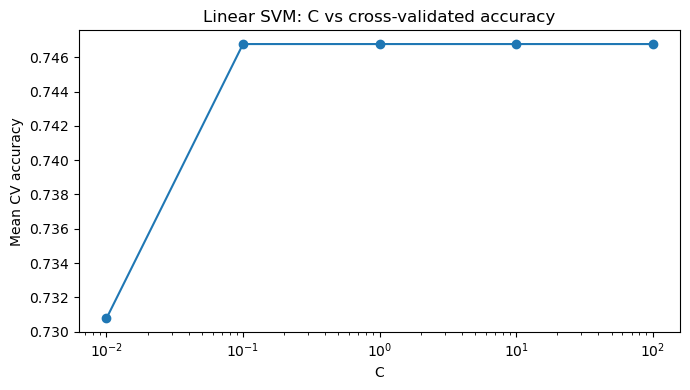

Best C: 0.1


In [9]:
plt.figure(figsize=(7, 4))
plt.semilogx(cv_df["C"], cv_df["cv_mean_accuracy"], marker="o")
plt.xlabel("C")
plt.ylabel("Mean CV accuracy")
plt.title("Linear SVM: C vs cross-validated accuracy")
plt.tight_layout()
plt.show()

best_linear_C = cv_df.loc[cv_df["cv_mean_accuracy"].idxmax(), "C"]
print("Best C:", best_linear_C)



### Interpretation
- **Very small \(C\)** allows more margin violations and may underfit.
- **Very large \(C\)** penalizes violations strongly and may overfit noise.
- The best \(C\) is the one with the highest validation accuracy, not necessarily the largest one.
